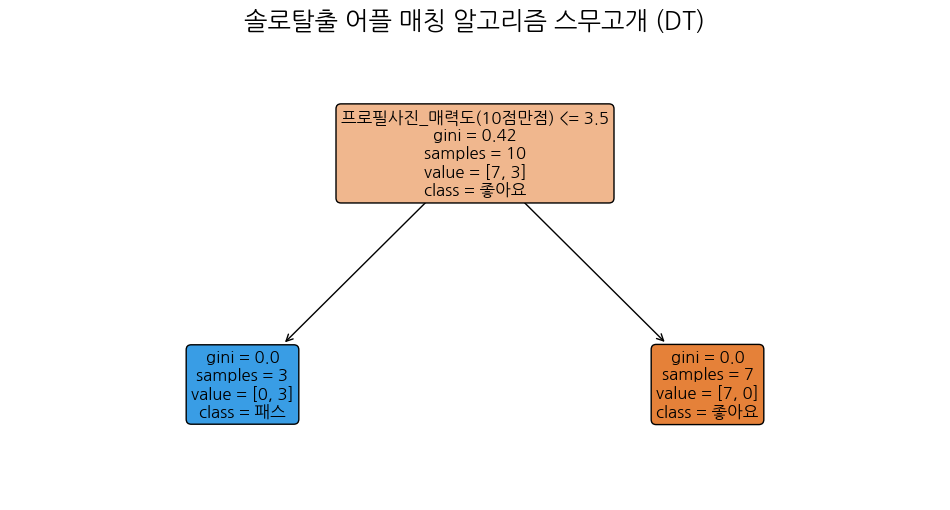

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import urllib.request
from sklearn.tree import DecisionTreeClassifier, plot_tree

# =========================================================================
# [필수] 시스템 권한 없는 환경을 위한 나눔고딕 폰트 강제 주입 우회 코드
# =========================================================================
font_url = "https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf"
font_path = "./NanumGothic-Regular.ttf"

if not os.path.exists(font_path):
    print("나눔고딕 폰트를 다운로드 중입니다...")
    urllib.request.urlretrieve(font_url, font_path)
    print("다운로드 완료!")

# Matplotlib에 다운로드한 폰트 등록
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
# =========================================================================

# 1. 도파민 폭발 가상 데이터 생성 (데이팅 어플 유저 행동)
data = {
    '연락빈도(하루_몇번)': [1, 10, 20, 2, 5, 0, 15, 30, 2, 8],
    '티키타카_유머점수(10점만점)': [2, 8, 9, 3, 7, 1, 8, 9, 4, 6],
    '프로필사진_매력도(10점만점)': [3, 4, 8, 9, 5, 2, 9, 7, 8, 3],
    '매칭결과': ['패스', '좋아요', '좋아요', '좋아요', '좋아요', '패스', '좋아요', '좋아요', '좋아요', '패스']
}

df = pd.DataFrame(data)

# 독립변수(X)와 종속변수(y) 분리
X = df[['연락빈도(하루_몇번)', '티키타카_유머점수(10점만점)', '프로필사진_매력도(10점만점)']]
y = df['매칭결과']

# 2. 의사결정나무(DT) 모델 학습
dt_model = DecisionTreeClassifier(max_depth=2, random_state=42)
dt_model.fit(X, y)

# 3. 유저들의 "호감 심리 스무고개" 차트 생성
plt.figure(figsize=(12, 6)) # 글자가 잘 보이기 위해 가로 크기를 살짝 늘렸습니다.
plot_tree(dt_model,
          feature_names=X.columns,
          class_names=dt_model.classes_,
          filled=True, rounded=True, fontsize=12)

plt.title("솔로탈출 어플 매칭 알고리즘 스무고개 (DT)", fontsize=18)
plt.show()

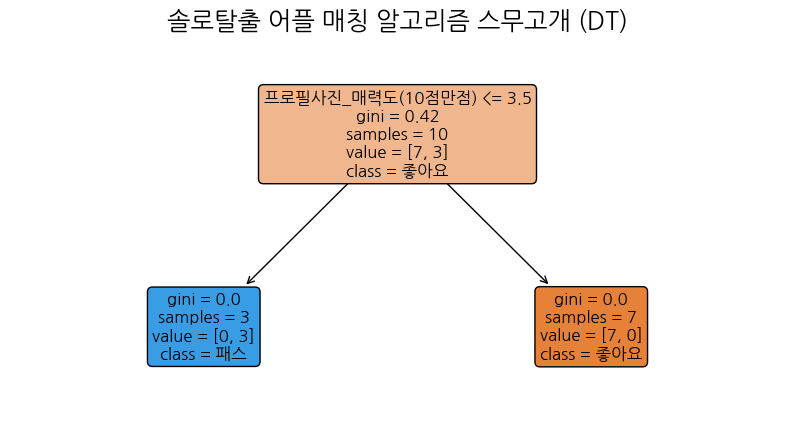

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

plt.rcParams ['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus' ] = False

# 1. 도파민 폭발 가상 데이터 생성 (데이팅 어플 유저 행동)
# (주의: 교육용으로 극단적으로 세팅된 가상 데이터입니다)
data = {
'연락빈도(하루_몇번)': [1, 10, 20, 2, 5, 0, 15, 30, 2, 8],
'티키타카_유머점수(10점만점)': [2, 8, 9, 3, 7, 1, 8, 9, 4, 6],
'프로필사진_매력도(10점만점)': [3, 4, 8, 9, 5, 2, 9, 7, 8, 3],
'매칭결과': ['패스', '좋아요', '좋아요', '좋아요', '좋아요', '패스', '좋아요', '좋아요', '좋아요', '패스']
}

df = pd.DataFrame(data)

# 독립변수(X)와 종속변수(y) 분리
X = df[['연락빈도(하루_몇번)', '티키타카_유머점수(10점만점)', '프로필사진_매력도(10점만점)']]
y = df[ '매칭결과']

# 2. 의사결정나무(DT) 모델 학습
dt_model = DecisionTreeClassifier(max_depth=2, random_state=42)
dt_model.fit(X, y)

# 3. 유저들의 "호감 심리 스무고개" 차트 생성
plt.figure(figsize=(10, 5))
plot_tree(dt_model,
feature_names=X. columns,
class_names=dt_model. classes_,
filled=True, rounded=True, fontsize=12)

plt.title("솔로탈출 어플 매칭 알고리즘 스무고개 (DT)", fontsize=18)
plt.show()

# [획 [교수님 설명 팁]
# "차트를 뽑아보니 가장 꼭대기에 뭐가 있나요? '티키타카 유머점수 <= 2.5' 혹은 '프로필 매력도 <= 4' 같은 게 떴을
# 이걸 보고 마케팅 팀장님께 이렇게 보고하는 겁니다.
# '팀장님! 우리 앱 유저들은 연락을 하루 100번 해도 소용없습니다, 일단 프로필 매력도가 4점 이상을 넘기지 못하면
# 밑에 트리 조건(연락/유머)은 타보지도 못하고 100% 무조건 [패스] 당합니다!'
# 사람의 심리(인과관계)를 무 자르듯 팩트 폭행해 주는 게 바로 DT입니다."